In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

# Convert into dataframe
df = pd.concat([X,y], axis=1)

# variable information 
print(cdc_diabetes_health_indicators.variables) 
print(df.columns)

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

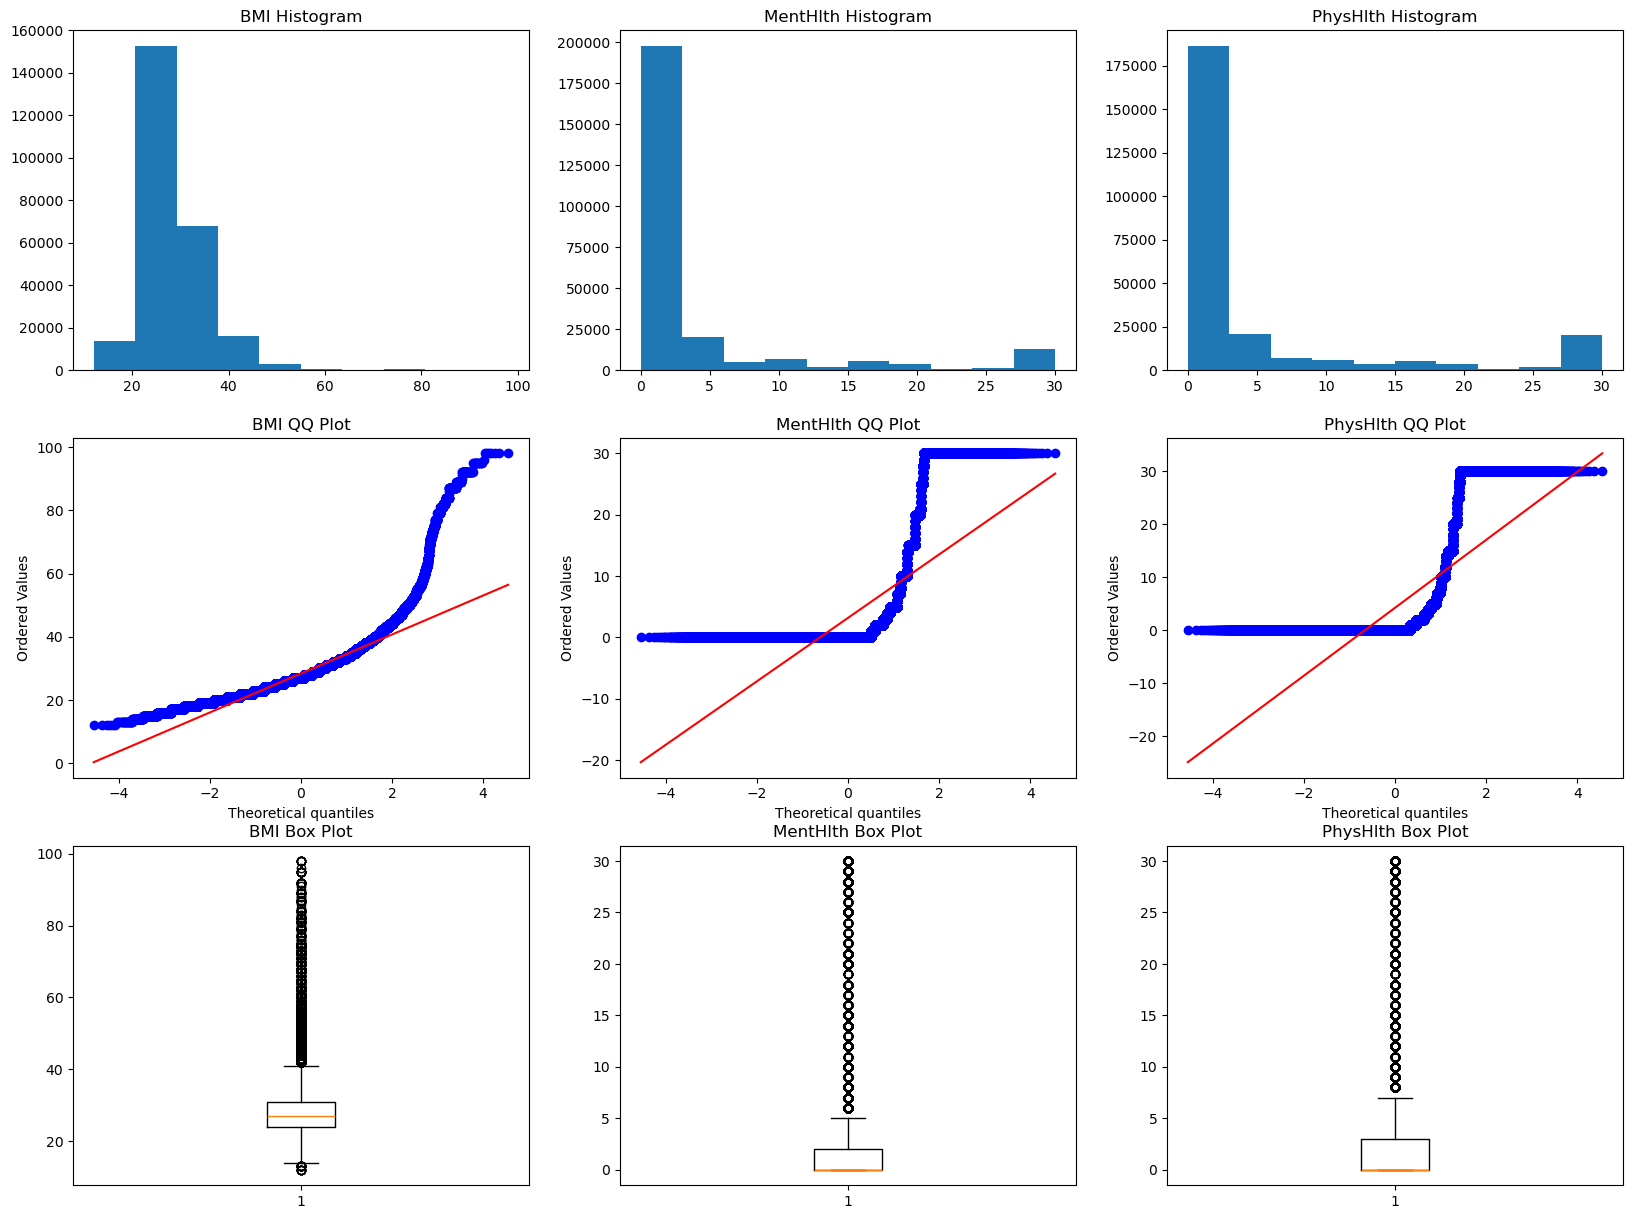

In [4]:
# Visualize the 3 Quantitative Variables: BMI, MentHlth, PhysHlth
quant_vars = ['BMI', 'MentHlth', 'PhysHlth']
fig, axes = plt.subplots(3, len(quant_vars), figsize=(20,15))
for i in range(len(quant_vars)):
    axes[0,i].hist(df[quant_vars[i]], bins=10)
    axes[0,i].set_title(quant_vars[i]+' Histogram')
    stats.probplot(df[quant_vars[i]].dropna(), dist="norm", plot=axes[1,i])
    axes[1,i].set_title(quant_vars[i]+' QQ Plot')
    axes[2,i].boxplot(df[quant_vars[i]])
    axes[2,i].set_title(quant_vars[i]+' Box Plot')
plt.show()

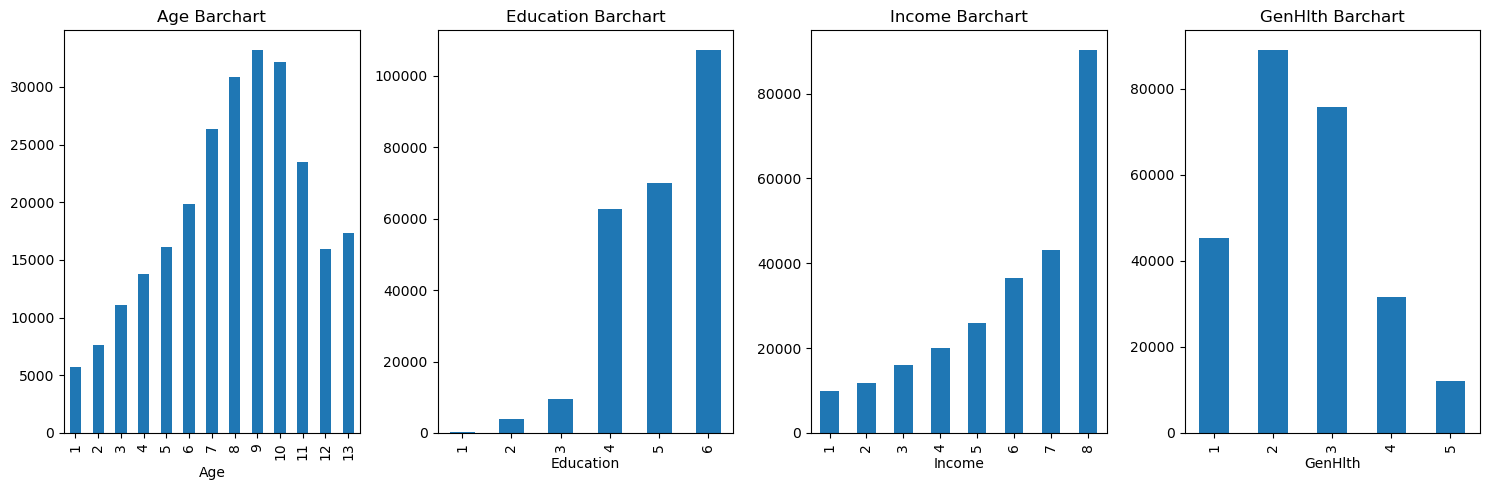

In [5]:
# Visualize the 4 Categorical Variables: Age, Education, Income, GenHlth
cat_vars = ['Age', 'Education', 'Income', 'GenHlth']
fig, axes = plt.subplots(1, len(cat_vars), figsize=(15,5))
for i in range(len(cat_vars)):
    df[cat_vars[i]].value_counts().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_title(cat_vars[i]+' Barchart')
plt.tight_layout()
plt.show()

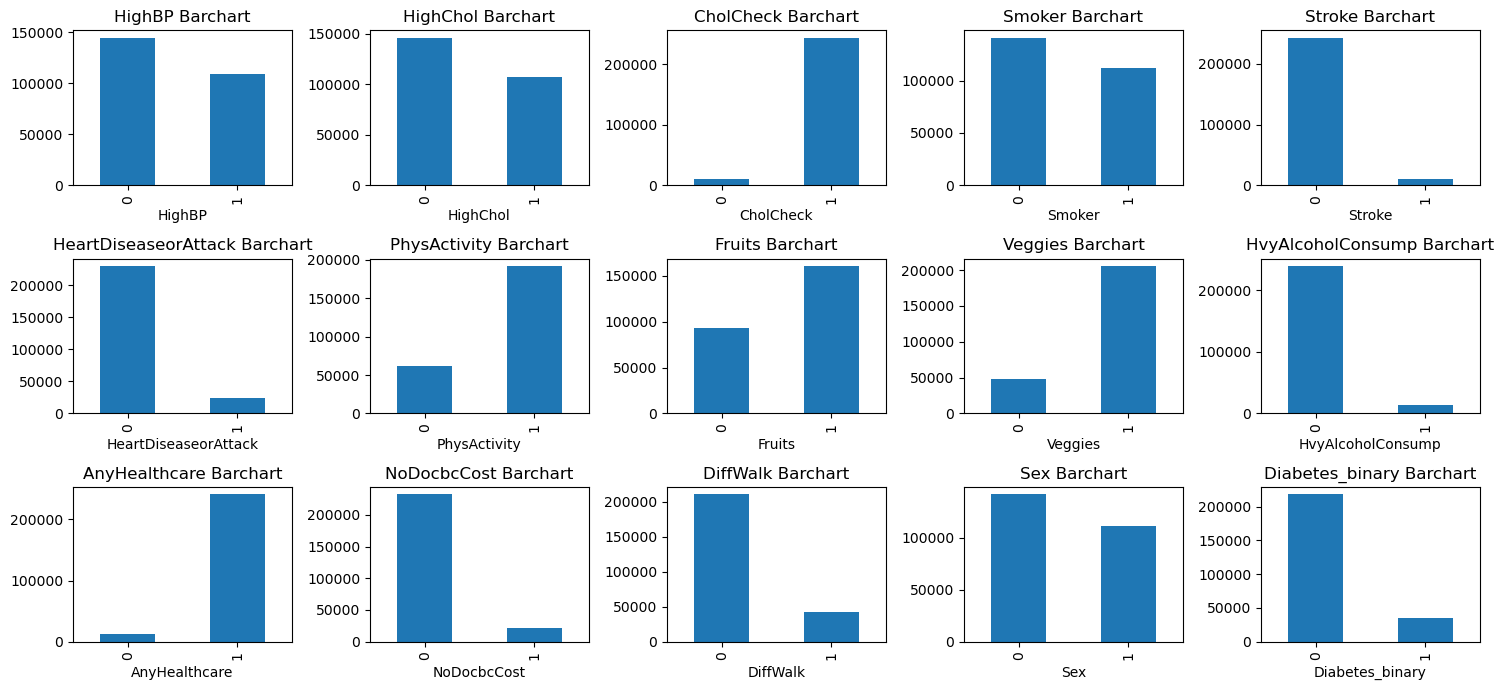

In [6]:
# Visualize the 15 Categorical Binary Variables: 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
       #'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       #'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'Diabetes_binary'
binary_vars = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'Diabetes_binary']

fig, axes = plt.subplots(3, 5, figsize=(15,7))
for i in range(3):
    for j in range(5):
        df[binary_vars[i*5+j]].value_counts().sort_index().plot(kind='bar', ax=axes[i,j])
        axes[i,j].set_title(binary_vars[i*5+j]+' Barchart')
plt.tight_layout()
plt.show()

In [10]:
# PROBLEM 1: Binary Classification Problem
# Predict: Does a patient have a health condition or not?
# Counting these as health conditions: (diabetic/prediabetic, high cholesterol, high BP, has had stroke, has had heart disease/attack)

df1 = df.copy()
df1['NumHealthConditions'] = (
    df['Diabetes_binary'] +
    df['HighBP'] +
    df['HighChol'] +
    df['Stroke'] +
    df['HeartDiseaseorAttack']
)
df1['HealthCondition'] = df1['NumHealthConditions'].apply(lambda x: 0 if x == 0 else 1)
df1 = df1.drop(columns = 'NumHealthConditions') # drop the intermediate column used to get the final target var
df1 = df1.drop(columns = ['Diabetes_binary', 'HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']) 
# drop the predictor variables that the target var is derived from to avoid data leakage, we still have over 10 explanatory variables

print((df1['HealthCondition'] == 0).sum())
print((df1['HealthCondition'] == 1).sum())
print(df1.head())
df1.to_csv('HealthProb1.csv', index=False)

94336
159344
   CholCheck  BMI  Smoker  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  \
0          1   40       1             0       0        1                  0   
1          0   25       1             1       0        0                  0   
2          1   28       0             0       1        0                  0   
3          1   27       0             1       1        1                  0   
4          1   24       0             1       1        1                  0   

   AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  \
0              1            0        5        18        15         1    0   
1              0            1        3         0         0         0    0   
2              1            1        5        30        30         1    0   
3              1            0        2         0         0         0    0   
4              1            0        2         3         0         0    0   

   Age  Education  Income  HealthCondition  
0   

In [11]:
# PROBLEM 2: Multiclass Classification Problem
# Predict: What level of health risk is a patient at?
# Low level 0: no health condition at all (good), medium level 1: 1-2 health conditions (iffy), high level 2: 3+ health conditions (bad)
df2 = df.copy()
df2['NumHealthConditions'] = (
    df['Diabetes_binary'] +
    df['HighBP'] +
    df['HighChol'] +
    df['Stroke'] +
    df['HeartDiseaseorAttack']
)

# Split patients into 3 categories based on the number of health conditions they have. This is the multiclass classification target var
def getRiskLevel(x):
    if x == 0:
        return 0
    elif x <= 2:
        return 1
    else:
        return 2

df2['RiskLevel'] = df2['NumHealthConditions'].apply(getRiskLevel)
df2 = df2.drop(columns = 'NumHealthConditions') # drop the intermediate column used to get the final target var
df2 = df2.drop(columns = ['Diabetes_binary', 'HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']) 
# drop the predictor variables that the target var is derived from to avoid data leakage, we still have over 10 explanatory variables

print((df2['RiskLevel'] == 0).sum())
print((df2['RiskLevel'] == 1).sum())
print((df2['RiskLevel'] == 2).sum())
print(df2.head())
df2.to_csv('HealthProb2.csv', index=False)

94336
126546
32798
   CholCheck  BMI  Smoker  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  \
0          1   40       1             0       0        1                  0   
1          0   25       1             1       0        0                  0   
2          1   28       0             0       1        0                  0   
3          1   27       0             1       1        1                  0   
4          1   24       0             1       1        1                  0   

   AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  \
0              1            0        5        18        15         1    0   
1              0            1        3         0         0         0    0   
2              1            1        5        30        30         1    0   
3              1            0        2         0         0         0    0   
4              1            0        2         3         0         0    0   

   Age  Education  Income  RiskLevel  
0   